In [1]:
import pandas as pd
import numpy as np
import os
import zipfile
from google.colab import drive

In [2]:
drive.mount('/content/drive')

Mounted at /content/drive


--- PHASE 3: LOADING UCI DATASET ---
Total Windows Loaded: 7352
--- PHASE 4: EXTRACTING 75 FEATURES PER WINDOW ---
--- PHASE 6: TRAINING RANDOM FOREST ---
Model Weights Saved Successfully.
--- PHASE 7: GENERATING EVALUATION REPORTS ---

Detailed Performance Matrix:
               precision    recall  f1-score   support

        Walk       0.98      0.98      0.98       245
    Upstairs       0.98      0.98      0.98       215
  Downstairs       0.97      0.97      0.97       197
         Sit       0.98      0.95      0.97       257
       Stand       0.96      0.98      0.97       275
         Lay       1.00      1.00      1.00       282

    accuracy                           0.98      1471
   macro avg       0.98      0.98      0.98      1471
weighted avg       0.98      0.98      0.98      1471

✅ Confusion Matrix saved at: /content/drive/MyDrive/FINAL_EXPORT/RFUCIONLY/uci_confusion_matrix.png


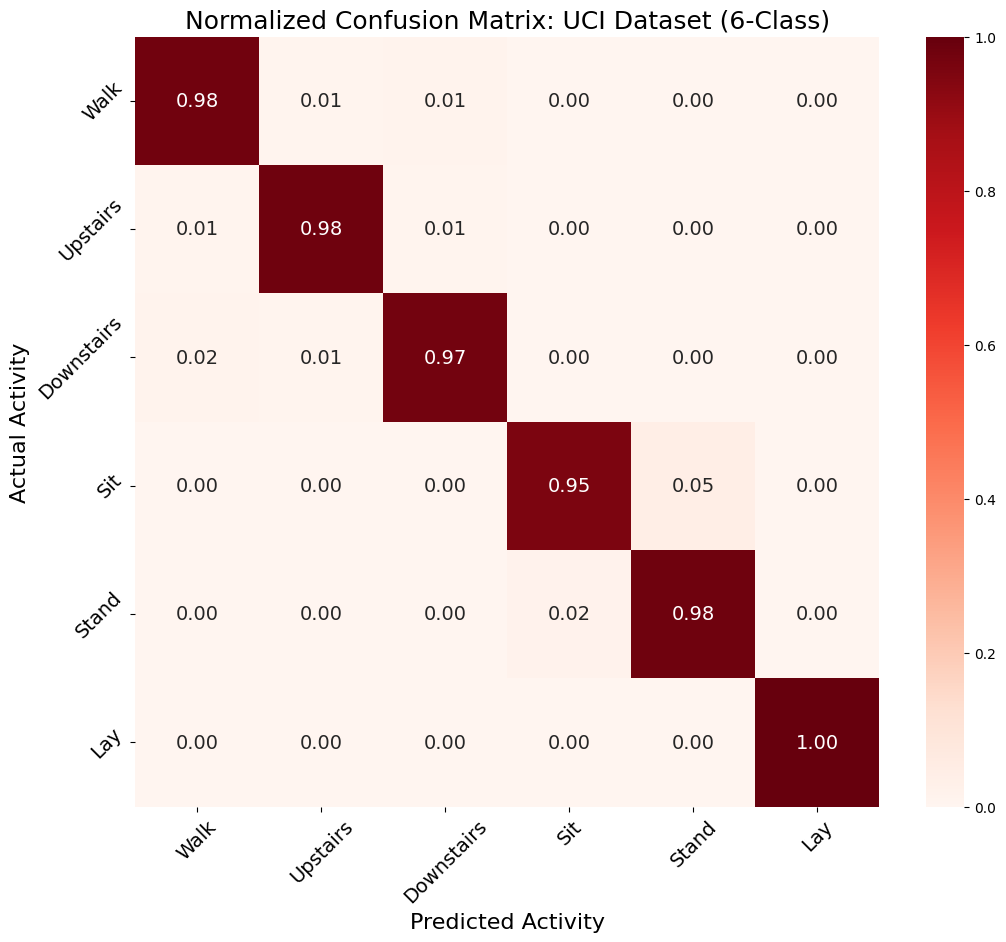

--- PHASE 8: FEATURE IMPORTANCE ANALYSIS ---


/tmp/ipykernel_646/1014984216.py:146: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices[:20]], y=[names[i] for i in indices[:20]], palette="viridis")


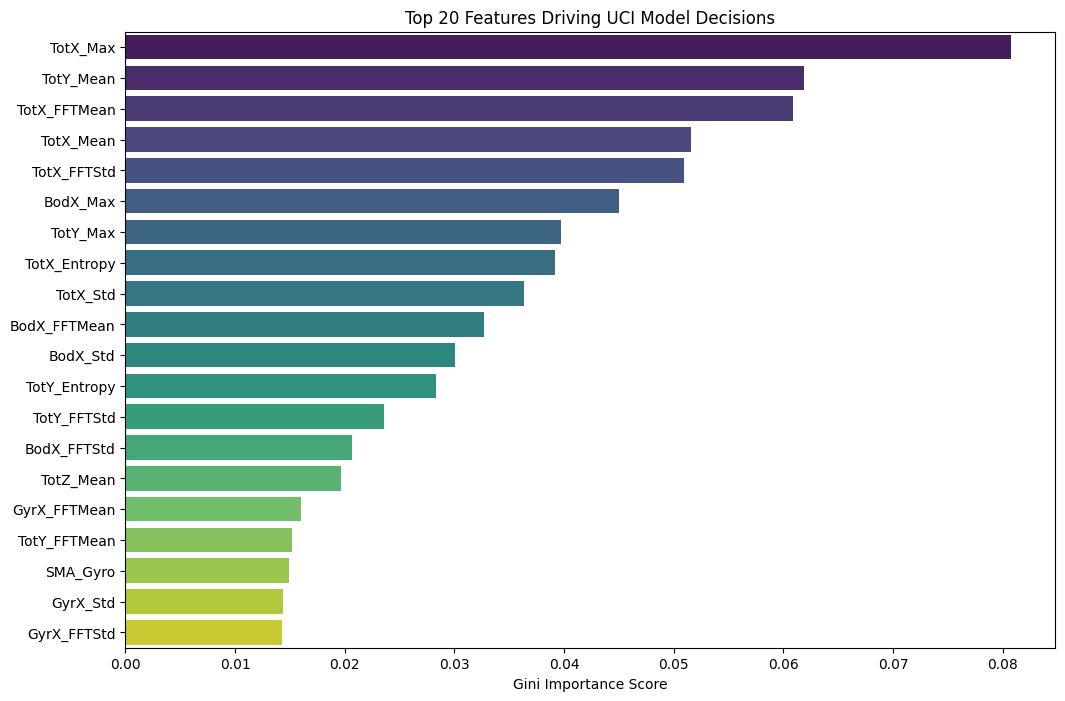

In [5]:
import pandas as pd
import numpy as np
import os
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis
from scipy.fftpack import fft
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# =================================================================================
# PHASE 1: DIRECTORY SETUP
# =================================================================================
def setup_directories():
    path = "/content/drive/MyDrive/FINAL_EXPORT/RFUCIONLY/"
    if not os.path.exists(path):
        os.makedirs(path)
    return path

# =================================================================================
# PHASE 2: FEATURE EXTRACTION ENGINE (75 FEATURES)
# =================================================================================
def extract_75_features(window):
    """
    Input: (128, 9) raw signal window
    Output: (75,) feature vector
    """
    features = []
    for i in range(9):
        sig = window[:, i]
        # Time domain (5)
        features.extend([np.mean(sig), np.std(sig), np.max(sig), skew(sig), kurtosis(sig)])
        # Frequency domain (3)
        sig_fft = np.abs(fft(sig))[:64]
        psd = sig_fft**2 / 64
        psd_norm = psd / (np.sum(psd) + 1e-12)
        entropy = -np.sum(psd_norm * np.log2(psd_norm + 1e-12))
        features.extend([np.mean(sig_fft), np.std(sig_fft), entropy])
    # Global magnitude features (3)
    sma_total = np.mean(np.sum(np.abs(window[:, 0:3]), axis=1))
    sma_body  = np.mean(np.sum(np.abs(window[:, 3:6]), axis=1))
    sma_gyro  = np.mean(np.sum(np.abs(window[:, 6:9]), axis=1))
    features.extend([sma_total, sma_body, sma_gyro])
    return np.array(features[:75])

# =================================================================================
# PHASE 3: UCI DATASET LOADING (6 CLASSES)
# =================================================================================
def load_uci_data():
    print("--- PHASE 3: LOADING UCI DATASET ---")
    BASE = "/content/drive/MyDrive/old_har/har_models_30.12.2025_ucrdataset_V2/UCI HAR Dataset/train/"
    SIG_PATH = os.path.join(BASE, "Inertial Signals/")
    files = [
        'total_acc_x_train.txt', 'total_acc_y_train.txt', 'total_acc_z_train.txt',
        'body_acc_x_train.txt', 'body_acc_y_train.txt', 'body_acc_z_train.txt',
        'body_gyro_x_train.txt', 'body_gyro_y_train.txt', 'body_gyro_z_train.txt'
    ]
    raw_signals = [np.loadtxt(os.path.join(SIG_PATH, f)) for f in files]
    X_raw = np.stack(raw_signals, axis=2)
    y_raw = np.loadtxt(os.path.join(BASE, "y_train.txt"))
    print(f"Total Windows Loaded: {X_raw.shape[0]}")
    return X_raw, y_raw

# =================================================================================
# PHASE 4: FEATURE PROCESSING
# =================================================================================
def process_features(X_raw, y_raw):
    print("--- PHASE 4: EXTRACTING 75 FEATURES PER WINDOW ---")
    X_feat = np.array([extract_75_features(w) for w in X_raw])
    y_feat = y_raw.astype(int)
    return X_feat, y_feat

# =================================================================================
# PHASE 5: DATA SPLITTING (80/20 STRATIFIED)
# =================================================================================
def split_uci_data(X, y):
    return train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# =================================================================================
# PHASE 6: RF TRAINING AND MODEL EXPORT
# =================================================================================
def train_and_save_model(X_train, y_train, save_dir):
    print("--- PHASE 6: TRAINING RANDOM FOREST ---")
    rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    joblib.dump(rf, os.path.join(save_dir, "uci_only_rf_model.pkl"))
    print("Model Weights Saved Successfully.")
    return rf

# =================================================================================
# PHASE 7: CONFUSION MATRIX AND PERFORMANCE EVALUATION
# =================================================================================
def evaluate_performance(model, X_test, y_test, save_dir):
    print("--- PHASE 7: GENERATING EVALUATION REPORTS ---")
    classes = ['Walk', 'Upstairs', 'Downstairs', 'Sit', 'Stand', 'Lay']
    y_pred = model.predict(X_test)

    # Classification Report
    report = classification_report(y_test, y_pred, target_names=classes)
    print("\nDetailed Performance Matrix:\n", report)

    # Normalized Confusion Matrix
    cm = confusion_matrix(y_test, y_pred, normalize='true')
    plt.figure(figsize=(12, 10))
    sns.heatmap(
        cm,
        annot=True,
        fmt='.2f',
        cmap='Reds',
        xticklabels=classes,
        yticklabels=classes,
        annot_kws={"size":14}  # font inside cells
    )

    plt.title('Normalized Confusion Matrix: UCI Dataset (6-Class)', fontsize=18)
    plt.xlabel('Predicted Activity', fontsize=16)
    plt.ylabel('Actual Activity', fontsize=16)

    plt.xticks(rotation=45, fontsize=14)
    plt.yticks(rotation=45, fontsize=14)

    # Save figure
    save_path = os.path.join(save_dir, 'uci_confusion_matrix.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"✅ Confusion Matrix saved at: {save_path}")
    plt.show()

# =================================================================================
# PHASE 8: FEATURE IMPORTANCE RANKING
# =================================================================================
def plot_importance(model, save_dir):
    print("--- PHASE 8: FEATURE IMPORTANCE ANALYSIS ---")
    importances = model.feature_importances_
    indices = np.argsort(importances)[::-1]

    names = []
    channels = ['TotX','TotY','TotZ','BodX','BodY','BodZ','GyrX','GyrY','GyrZ']
    stats = ['Mean','Std','Max','Skew','Kurt','FFTMean','FFTStd','Entropy']
    for ch in channels:
        for s in stats: names.append(f"{ch}_{s}")
    names.extend(['SMA_Total','SMA_Body','SMA_Gyro'])

    plt.figure(figsize=(12,8))
    sns.barplot(x=importances[indices[:20]], y=[names[i] for i in indices[:20]], palette="viridis")
    plt.title('Top 20 Features Driving UCI Model Decisions')
    plt.xlabel('Gini Importance Score')
    plt.savefig(os.path.join(save_dir, 'uci_feature_importance.png'), dpi=300)
    plt.show()

# =================================================================================
# MAIN EXECUTION
# =================================================================================
output_path = setup_directories()
X_raw, y_raw = load_uci_data()
X_f, y_f = process_features(X_raw, y_raw)
X_tr, X_ts, y_tr, y_ts = split_uci_data(X_f, y_f)
uci_model = train_and_save_model(X_tr, y_tr, output_path)
evaluate_performance(uci_model, X_ts, y_ts, output_path)
plot_importance(uci_model, output_path)

# CONVERT TO MLPACKAGE

In [2]:
!pip install scikit-learn==1.5.2 coremltools pandas numpy matplotlib scipy joblib --upgrade

In [3]:
import joblib
import coremltools as ct
import os
import shutil
import numpy as np

# 1. Define paths with standard mlpackage format
PKL_PATH = '/content/drive/MyDrive/FINAL_EXPORT/RFUCIONLY/uci_only_rf_model.pkl'
COREML_SAVE_PATH = '/content/drive/MyDrive/FINAL_EXPORT/RFUCIONLY/uci_75_string.mlpackage'

print(f"Loading the UCI model from: {PKL_PATH}")

if not os.path.exists(PKL_PATH):
    print("Error: PKL file not found. Please run the training script first.")
else:
    # 2. Load the model
    rf_model = joblib.load(PKL_PATH)

    # 3. Define mapping for class labels (upper-case) to match Swift
    uci_label_map = {
        1: 'WALKING',
        2: 'UPSTAIRS',
        3: 'DOWNSTAIRS',
        4: 'SITTING',
        5: 'STANDING',
        6: 'LAYING'
    }

    # 4. Replace numeric labels with string labels in model classes
    try:
        string_labels = [uci_label_map[int(c)] for c in rf_model.classes_]
        rf_model.classes_ = np.array(string_labels, dtype=object)
        print(f"✅ Mapped classes to: {rf_model.classes_}")
    except KeyError as e:
        print(f"❌ Mapping error: class {e} not found in uci_label_map. Check your labels.")

    # 5. Define input as a simple string for MultiArray input
    input_feature_name = "features_75"

    print("Converting to CoreML with string labels and MultiArray input...")

    try:
        # 6. Convert the model
        coreml_model = ct.converters.sklearn.convert(
            rf_model,
            input_features=input_feature_name,
            output_feature_names="classLabel"
        )

        # 7. Metadata
        coreml_model.author = "BEM"
        coreml_model.short_description = "UCI RF Model - 75 Features with MultiArray Input"

        # 8. Save logic for mlpackage (mlpackage is actually a folder)
        save_dir = os.path.dirname(COREML_SAVE_PATH)
        if save_dir:
            os.makedirs(save_dir, exist_ok=True)

        if os.path.exists(COREML_SAVE_PATH):
            if os.path.isdir(COREML_SAVE_PATH):
                shutil.rmtree(COREML_SAVE_PATH)  # Remove previous package folder
            else:
                os.remove(COREML_SAVE_PATH)

        # Save as mlpackage
        coreml_model.save(COREML_SAVE_PATH)
        print(f"✅ SUCCESS! Model saved as mlpackage at: {COREML_SAVE_PATH}")

    except Exception as e:
        print(f"❌ Conversion failed: {e}")

Loading the UCI model from: /content/drive/MyDrive/FINAL_EXPORT/RFUCIONLY/uci_only_rf_model.pkl


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.6.1 when using version 1.5.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.6.1 when using version 1.5.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


✅ Mapped classes to: ['WALKING' 'UPSTAIRS' 'DOWNSTAIRS' 'SITTING' 'STANDING' 'LAYING']
Converting to CoreML with string labels and MultiArray input...
✅ SUCCESS! Model saved as mlpackage at: /content/drive/MyDrive/FINAL_EXPORT/RFUCIONLY/uci_75_string.mlpackage
